In [1]:
import sqlite3
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

In [2]:
conn = sqlite3.connect("../data/raw/movies.db")

query_movie = """
SELECT *
FROM movies
"""
movies_df = pd.read_sql_query(query_movie, conn)

query_rating = """
SELECT *
FROM ratings
"""

ratings_df = pd.read_sql_query(query_rating, conn)

In [3]:
movies_df.columns = movies_df.columns.str.lower()
ratings_df.columns = ratings_df.columns.str.lower()

In [4]:
print(movies_df.dtypes)
print(ratings_df.dtypes)

movieid    int64
title        str
genres       str
dtype: object
userid         int64
movieid        int64
rating       float64
timestamp      int64
dtype: object


In [5]:
print('Movies DataFrame head:')
display(movies_df.head())

print('\nRatings DataFrame head:')
display(ratings_df.head())

Movies DataFrame head:


,movieid,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy



Ratings DataFrame head:


,userid,movieid,rating,timestamp
0,1,296,5.0,1147880044
1,1,306,3.5,1147868817
2,1,307,5.0,1147868828
3,1,665,5.0,1147878820
4,1,899,3.5,1147868510


In [6]:
ratings_df.isnull().sum()

userid       0
movieid      0
rating       0
timestamp    0
dtype: int64

In [7]:
movies_df.isnull().sum()

movieid    0
title      0
genres     0
dtype: int64

In [8]:
print("no of rows in movies_df: ", movies_df.shape[0])
print("no of rows in ratings_df: ", ratings_df.shape[0])

print("no of unique movies in movies_df: ", movies_df["movieid"].nunique())
print("no of unique movies in ratings_df: ", ratings_df["movieid"].nunique())
print("above suggests that there are some movies in movies_df not in ratings_df, i.e. few movies are not viewed/rated by any user !")
print("no of unique users in ratings_df: ", ratings_df["userid"].nunique())

no of rows in movies_df:  62423
no of rows in ratings_df:  25000095
no of unique movies in movies_df:  62423
no of unique movies in ratings_df:  59047
above suggests that there are some movies in movies_df not in ratings_df, i.e. few movies are not viewed/rated by any user !
no of unique users in ratings_df:  162541


In [10]:
movie_rating_df = pd.merge(
    ratings_df[["userid", "movieid", "rating"]],
    movies_df,
    on="movieid",
    how="inner"
)

print(movie_rating_df.isnull().sum())
print()
print(movie_rating_df.shape)
print()
movie_rating_df.head()

userid     0
movieid    0
rating     0
title      0
genres     0
dtype: int64

(25000095, 5)



,userid,movieid,rating,title,genres
0,1,296,5.0,Pulp Fiction (1994),Comedy|Crime|Drama|Thriller
1,1,306,3.5,Three Colors: Red (Trois couleurs: Rouge) (1994),Drama
2,1,307,5.0,Three Colors: Blue (Trois couleurs: Bleu) (1993),Drama
3,1,665,5.0,Underground (1995),Comedy|Drama|War
4,1,899,3.5,Singin' in the Rain (1952),Comedy|Musical|Romance


In [11]:
movie_rating_df["userid"].nunique()

162541

In [12]:
movie_rating_df["movieid"].nunique()

59047

rating
4.0    0.265591
3.0    0.195876
5.0    0.144498
3.5    0.127092
4.5    0.088021
2.0    0.065634
2.5    0.050512
1.0    0.031072
1.5    0.015980
0.5    0.015723
Name: proportion, dtype: float64


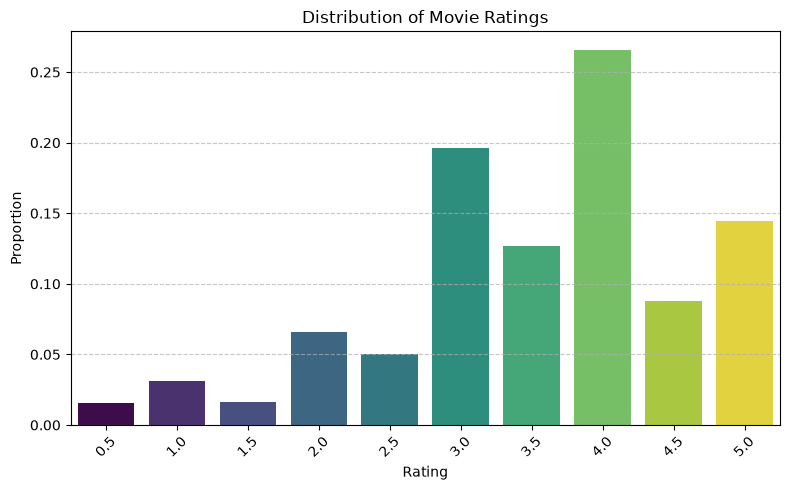

In [13]:
# Rating Distribution
print(movie_rating_df["rating"].value_counts(normalize=True, sort=True))

rating_distribution = movie_rating_df["rating"].value_counts(normalize=True).sort_index().reset_index()
rating_distribution.columns = ['rating', 'proportion']

plt.figure(figsize=(8, 5))
sns.barplot(x='rating', y='proportion', data=rating_distribution, palette='viridis', hue='rating', legend=False)
plt.title('Distribution of Movie Ratings')
plt.xlabel('Rating')
plt.ylabel('Proportion')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [14]:
print("mean rating: ", movie_rating_df["rating"].mean())
print("median rating: ", movie_rating_df["rating"].median())
print("most frequent rating: ", movie_rating_df["rating"].mode()[0])
print("min rating: ", movie_rating_df["rating"].min(), ",", "max rating: ", movie_rating_df["rating"].max())

mean rating:  3.533854451353085
median rating:  3.5
most frequent rating:  4.0
min rating:  0.5 , max rating:  5.0


title
Forrest Gump (1994)                          81491
Shawshank Redemption, The (1994)             81482
Pulp Fiction (1994)                          79672
Silence of the Lambs, The (1991)             74127
Matrix, The (1999)                           72674
Star Wars: Episode IV - A New Hope (1977)    68717
Jurassic Park (1993)                         64144
Schindler's List (1993)                      60411
Braveheart (1995)                            59184
Fight Club (1999)                            58773
Name: count, dtype: int64



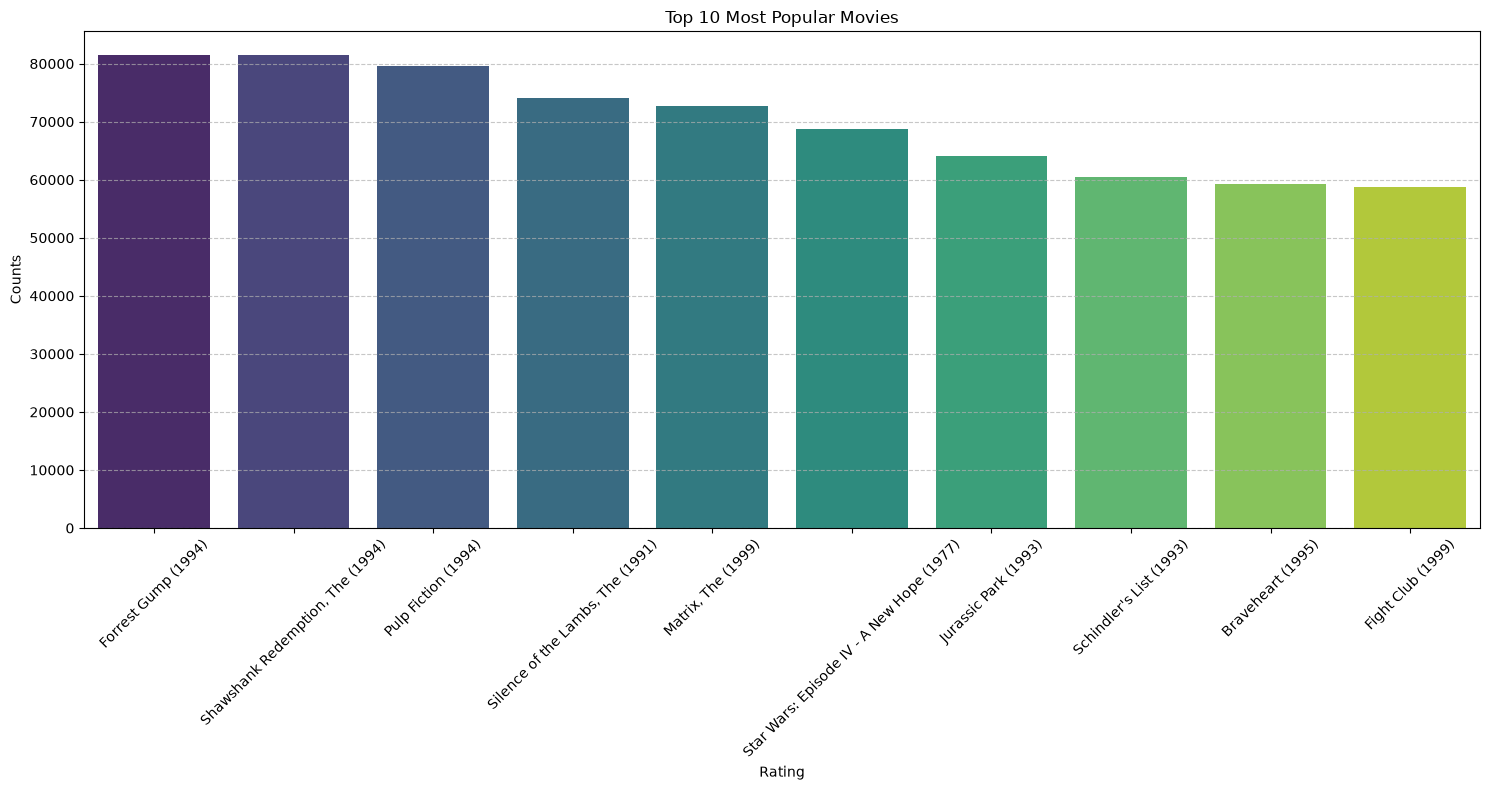

In [15]:
# Most Popular Movies
print(movie_rating_df["title"].value_counts().sort_values(ascending=False).head(10))
print()
top10_popular_movies = movie_rating_df["title"].value_counts().sort_values(ascending=False).head(10).reset_index()
top10_popular_movies.columns = ['title', 'counts']

plt.figure(figsize=(15, 8))
sns.barplot(x='title', y='counts', data=top10_popular_movies, palette='viridis', hue='title', legend=False)
plt.title('Top 10 Most Popular Movies')
plt.xlabel('Rating')
plt.ylabel('Counts')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [16]:
num_users = movie_rating_df["userid"].nunique()
num_movies = movie_rating_df["movieid"].nunique()
num_ratings = len(movie_rating_df)

possible_ratings = num_users * num_movies

density = num_ratings / possible_ratings
sparsity = 1 - density

print(f"Users: {num_users:,}")
print(f"Movies: {num_movies:,}")
print(f"Ratings: {num_ratings:,}")
print(f"Density: {density:.4%}")
print(f"Sparsity: {sparsity:.4%}")

Users: 162,541
Movies: 59,047
Ratings: 25,000,095
Density: 0.2605%
Sparsity: 99.7395%


In [17]:
user_rating_agg_df = movie_rating_df.groupby("userid").agg(
    min_rating = ("rating", "min"),
    max_rating = ("rating", "max"),
    num_ratings = ("rating", "count"),
    avg_rating = ("rating", "mean")
).reset_index()

print("avg no movies per user: ", user_rating_agg_df["num_ratings"].mean())
print()
user_rating_agg_df.head()

avg no movies per user:  153.80793153727367



,userid,min_rating,max_rating,num_ratings,avg_rating
0,1,0.5,5.0,70,3.814286
1,2,0.5,5.0,184,3.630435
2,3,2.0,5.0,656,3.697409
3,4,0.5,5.0,242,3.378099
4,5,2.0,5.0,101,3.752475


In [ ]:
file_path = Path("../data/processed/movie_rating_df.parquet")

if file_path.exists():
    print("File already exists — not overwriting.")
else:
    movie_rating_df.to_parquet(file_path, index=False, compression="snappy")
    print("File saved.")

File saved.
